<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Curso: Machine Learning</p>

<p style="text-align: center;"> Código Curso: 203008067 </p>

<p style="text-align: center;"> Grupo: 03 </p>

<p style="text-align: center;"> Fase 2 - Componente práctico - Algoritmos supervisados</p>

<p style="text-align: center;">  Presentado por: Wilmer Ricardo Urda</p>

<p style="text-align: center;"> Código: 101719427</p>

<p style="text-align: center;">  Tutor(a): Rafael Gaitan </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> 2026</p>

# Importación dataset

In [1]:
from sklearn.datasets import fetch_openml
dfr = fetch_openml(data_id=8, parser='auto') # Escriba en este espacio el id correspondientes al item escogido
dfc = fetch_openml(data_id=31, parser='auto')

# Ejercicio 1: Contextualización Dataset.

In [2]:
print(dfr.DESCR)

**Author**: BUPA Medical Research Ltd. Donor: Richard S. Forsyth   
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/Liver+Disorders) - 5/15/1990  
**Please cite**: 

**BUPA liver disorders**
 
The first 5 variables are all blood tests which are thought to be sensitive to liver disorders that might arise from excessive alcohol consumption.  Each line in the dataset constitutes the record of a single male individual. 

**Important note:** The 7th field (selector) has been widely misinterpreted in the past as a dependent variable representing presence or absence of a liver disorder. This is incorrect [1]. The 7th field was created by BUPA researchers as a train/test selector. It is not suitable as a dependent variable for classification. The dataset does not contain any variable representing presence or absence of a liver disorder. Researchers who wish to use this dataset as a classification benchmark should follow the method used in experiments by the donor (Forsyth & Rada, 198

In [3]:
dfr.frame.head()

,mcv,alkphos,sgpt,sgot,gammagt,drinks
0,85,92,45,27,31,0.0
1,85,64,59,32,23,0.0
2,86,54,33,16,54,0.0
3,91,78,34,24,36,0.0
4,87,70,12,28,10,0.0


In [4]:
dfr.frame.shape

(345, 6)

In [5]:
dfr.frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mcv      345 non-null    int64  
 1   alkphos  345 non-null    int64  
 2   sgpt     345 non-null    int64  
 3   sgot     345 non-null    int64  
 4   gammagt  345 non-null    int64  
 5   drinks   345 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 16.3 KB


In [6]:
print(dfc.DESCR)

**Author**: Dr. Hans Hofmann  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)) - 1994    
**Please cite**: [UCI](https://archive.ics.uci.edu/ml/citation_policy.html)

**German Credit dataset**  
This dataset classifies people described by a set of attributes as good or bad credit risks.

This dataset comes with a cost matrix: 
``` 
Good  Bad (predicted)  
Good   0    1   (actual)  
Bad    5    0  
```

It is worse to class a customer as good when they are bad (5), than it is to class a customer as bad when they are good (1).  

### Attribute description  

1. Status of existing checking account, in Deutsche Mark.  
2. Duration in months  
3. Credit history (credits taken, paid back duly, delays, critical accounts)  
4. Purpose of the credit (car, television,...)  
5. Credit amount  
6. Status of savings account/bonds, in Deutsche Mark.  
7. Present employment, in number of years.  
8. Installment rate in percentage of disposable income  
9. Perso

In [7]:
dfc.frame.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [8]:
dfc.frame.shape

(1000, 21)

In [9]:
dfc.frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1


###Contextualización
En esta primera parte tenemos dos datasets obtenidos desde OpenML mediante la librería sklearn. El primer dataset corresponde a **BUPA Liver Disorders**, el cual contiene resultados de pruebas sanguíneas relacionadas con posibles alteraciones hepáticas asociadas al consumo de alcohol. Este conjunto de datos está compuesto por 345 registros y 6 variables numéricas. Aunque no posee una variable objetivo explícita de enfermedad, comúnmente se emplea la variable drinks como variable dependiente tras su transformación. Las variables asociadas incluyen indicadores clínicos como mcv, alkphos, sgpt, sgot y gammagt.

El segundo dataset es de **German Credit**, cuyo propósito es clasificar a los solicitantes de crédito según su nivel de riesgo financiero. Este conjunto contiene 1000 registros y 21 variables de tipo categórico y numérico. La variable objetivo es class, que identifica si el cliente es buen o mal pagador. Las variables asociadas describen características financieras y personales del solicitante, tales como estado de cuenta, duración del crédito, historial crediticio, monto del préstamo, empleo, edad y vivienda.

# Ejercicio 2: Análisis cuantitativo y cualitativo.

**Primer dataset corresponde a BUPA Liver Disorders**

###Eliminación de valores nulos

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Crear copia del dataframe
df = dfr.frame.copy()

df.head()

,mcv,alkphos,sgpt,sgot,gammagt,drinks
0,85,92,45,27,31,0.0
1,85,64,59,32,23,0.0
2,86,54,33,16,54,0.0
3,91,78,34,24,36,0.0
4,87,70,12,28,10,0.0


In [11]:
##Eliminación de valores nulos
df.isnull().sum()
df = df.dropna()
df.shape

(345, 6)

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['mcv', 'alkphos', 'sgpt', 'sgot', 'gammagt', 'drinks'], dtype='object')

##Vizualizar Outliers (IQR)

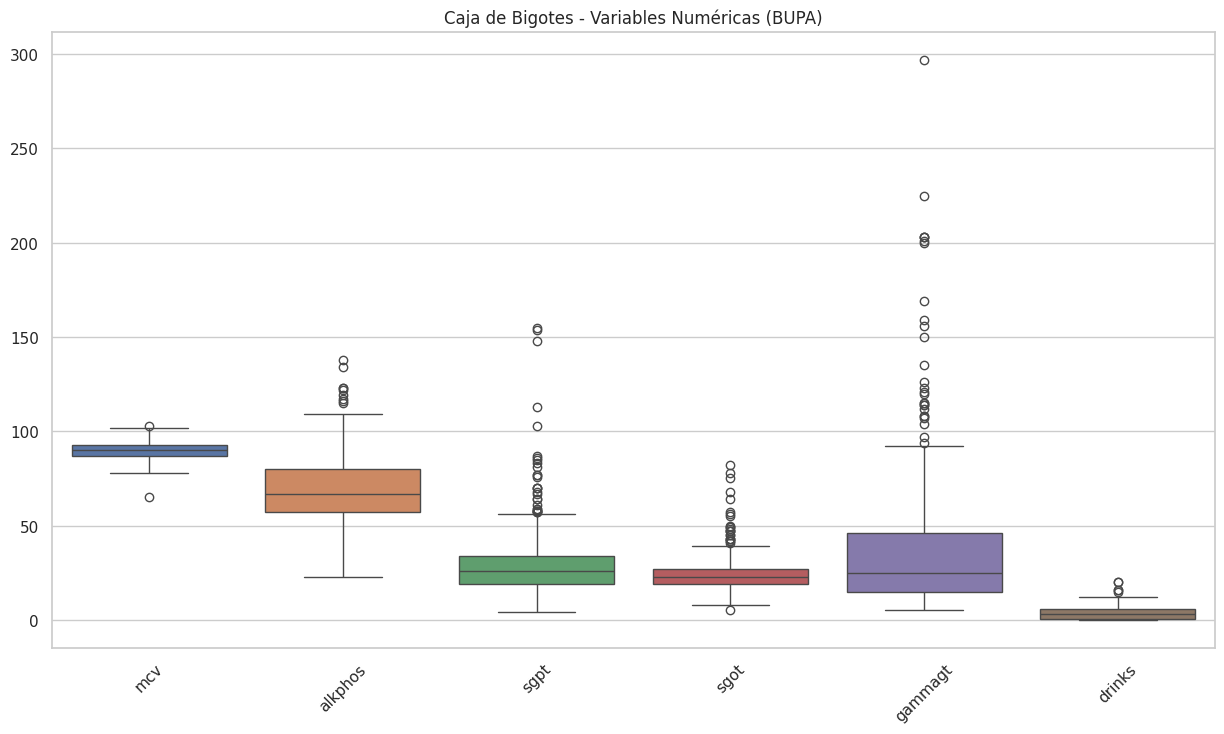

In [13]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[numeric_cols])
plt.title("Caja de Bigotes - Variables Numéricas (BUPA)")
plt.xticks(rotation=45)
plt.show()

En el anterior diagramas de cajas de Bigotes se pueden observar el comportamiento de los datos, como se distribuyen en las distintas variables, es evidente la presencia de oulierts o valores atipicos en el conjuntos de datos.

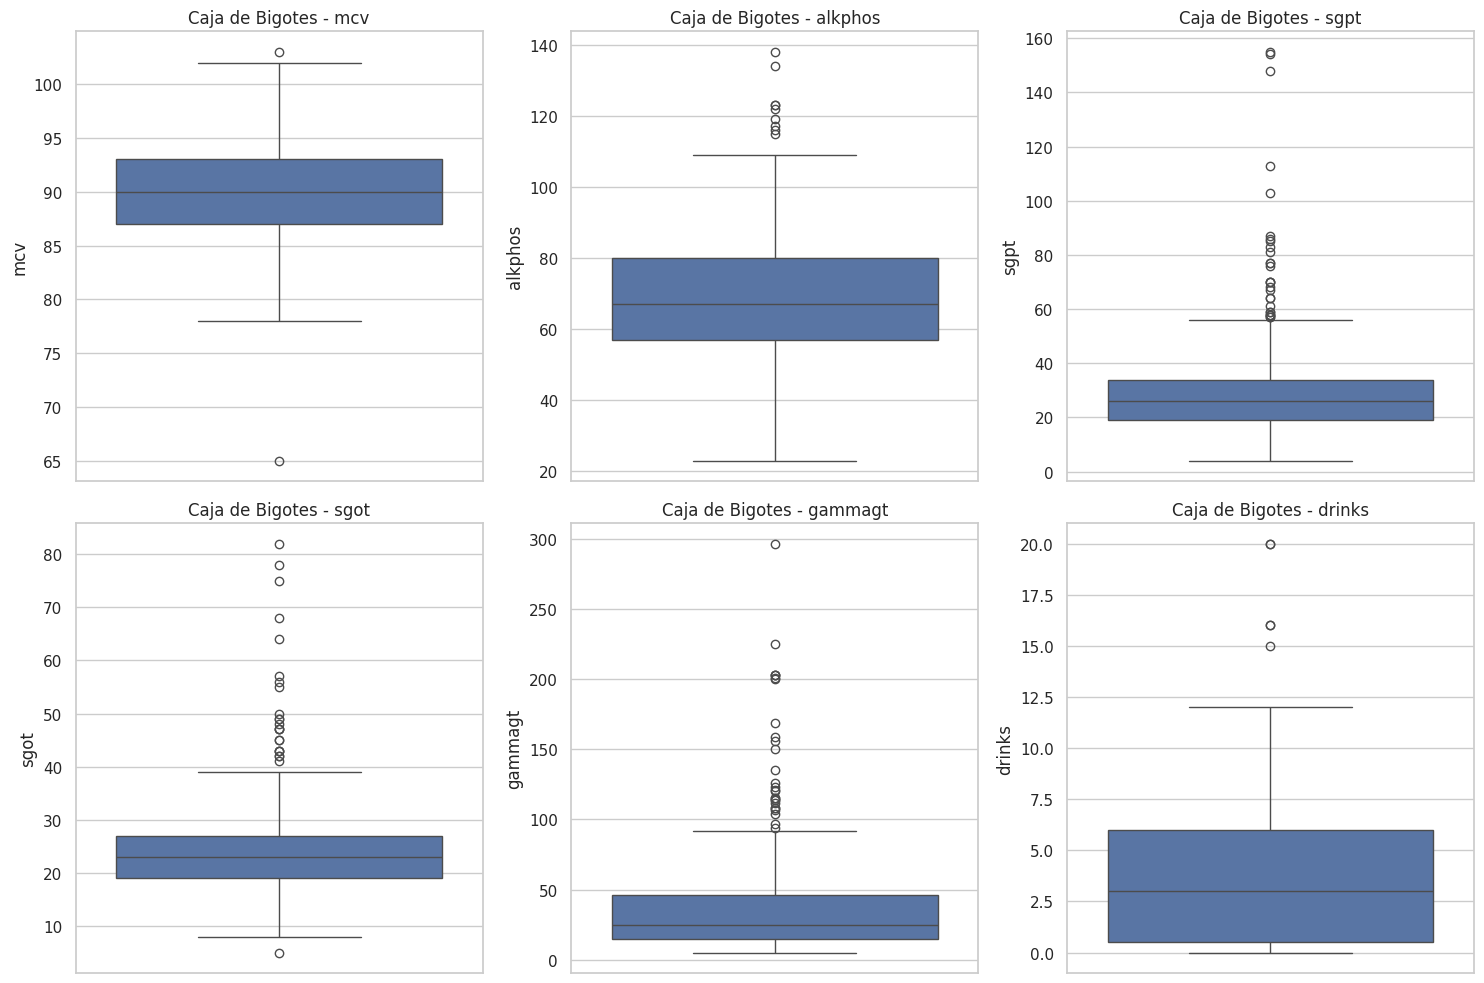

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Caja de Bigotes - {col}")

plt.tight_layout()
plt.show()

##Eliminación de Outliers (IQR)

In [14]:
def remove_outliers_iqr(data, factor=1.5):

    df_processed = data.copy()
    outlier_indices = pd.Index([]) # Inicializa un índice vacío para guardar los índices de los outliers

    # Seleccionar solo las columnas numéricas para el análisis de outliers
    numeric_cols = df_processed.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        Q1 = df_processed[col].quantile(0.25)
        Q3 = df_processed[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        # Identificar los índices de los outliers para la columna actual
        current_col_outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)].index
        # Unir los índices de los outliers de esta columna con los ya encontrados
        outlier_indices = outlier_indices.union(current_col_outliers)

    # Eliminar todas las filas identificadas como outliers en una sola operación
    df_cleaned = df_processed.drop(outlier_indices)

    return df_cleaned

df_clean = remove_outliers_iqr(df)

df_clean.shape

(281, 6)

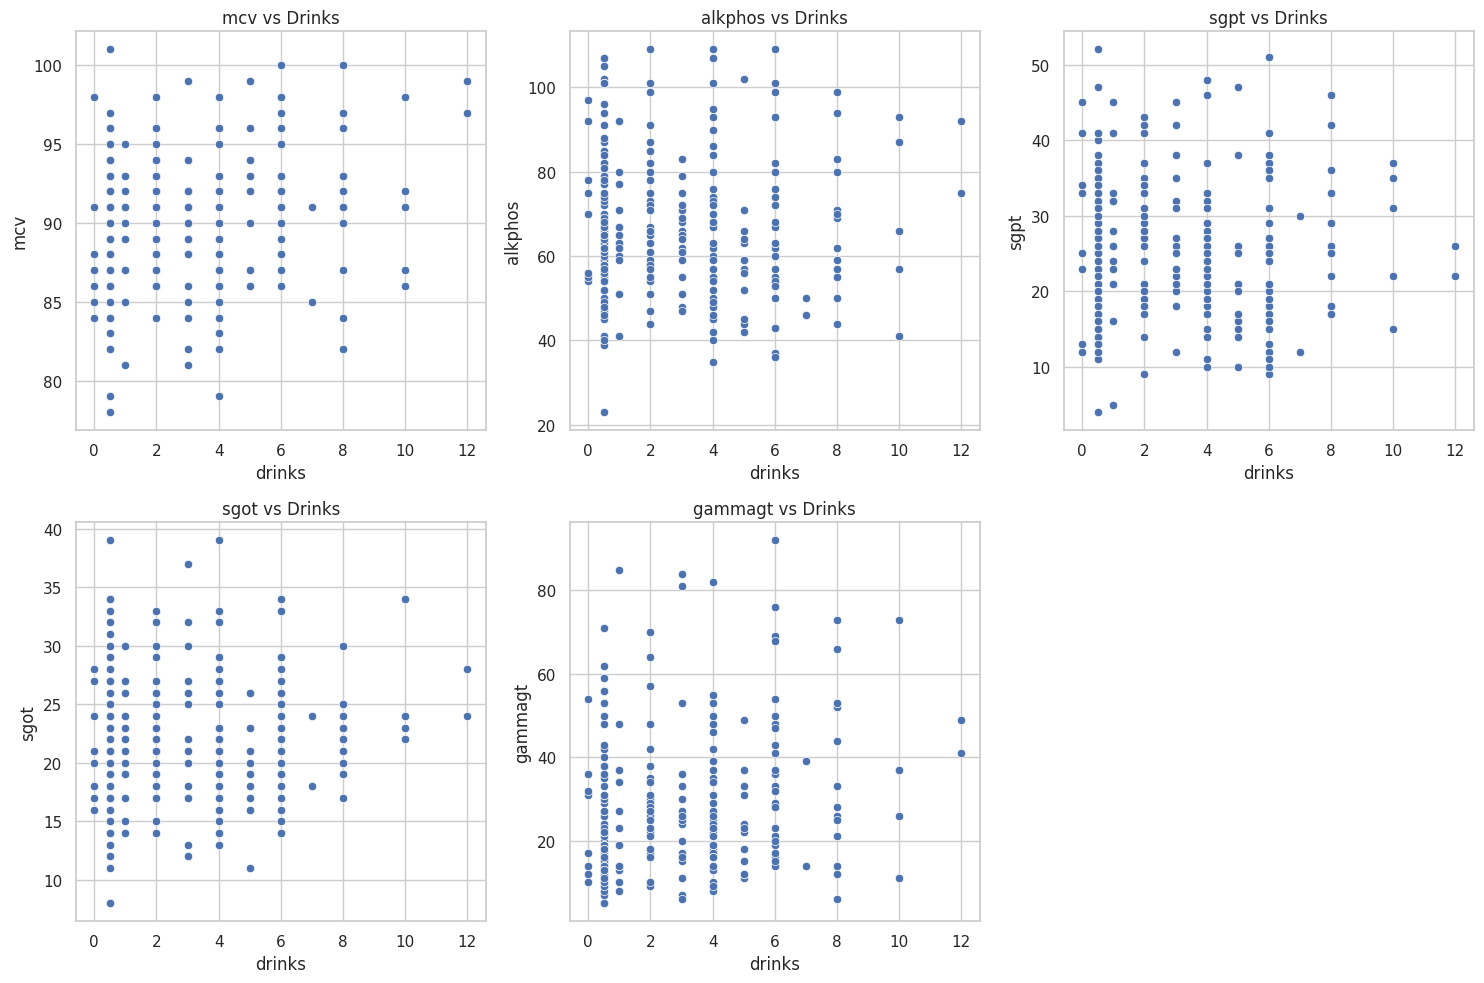

In [15]:
plt.figure(figsize=(15,10))

# Identificar las columnas numéricas relevantes para graficar contra 'drinks'
# Las columnas a graficar en el eje Y son todas excepto 'drinks' misma.
plotting_cols = [col for col in df_clean.columns if col != 'drinks']

for i, col in enumerate(plotting_cols):
    plt.subplot(2,3,i+1)
    sns.scatterplot(x=df_clean["drinks"], y=df_clean[col]) # Corregido: 'drinks' en el eje X, 'col' en el eje Y
    plt.title(f"{col} vs Drinks") # Título corregido

plt.tight_layout()
plt.show()

En los graficos anterios se muestran la relación entre el consumo de alcohol (drinks) y diferentes variables biomédicas del dataset. En general, se observa una alta dispersión de los puntos, lo que indica que no existe una relación lineal fuerte entre drinks y las demás variables. Sin embargo, se pueden identificar algunas tendencias leves: por ejemplo, en variables como gammagt y mcv se aprecia una ligera tendencia a aumentar a medida que crece el consumo de alcohol, lo cual es coherente con su comportamiento clínico. En el caso de sgpt y sgot, los datos están más dispersos, lo que sugiere una relación más débil o influenciada por otros factores. Por su parte, alkphos no muestra un patrón claro, evidenciando poca dependencia con el consumo de alcohol

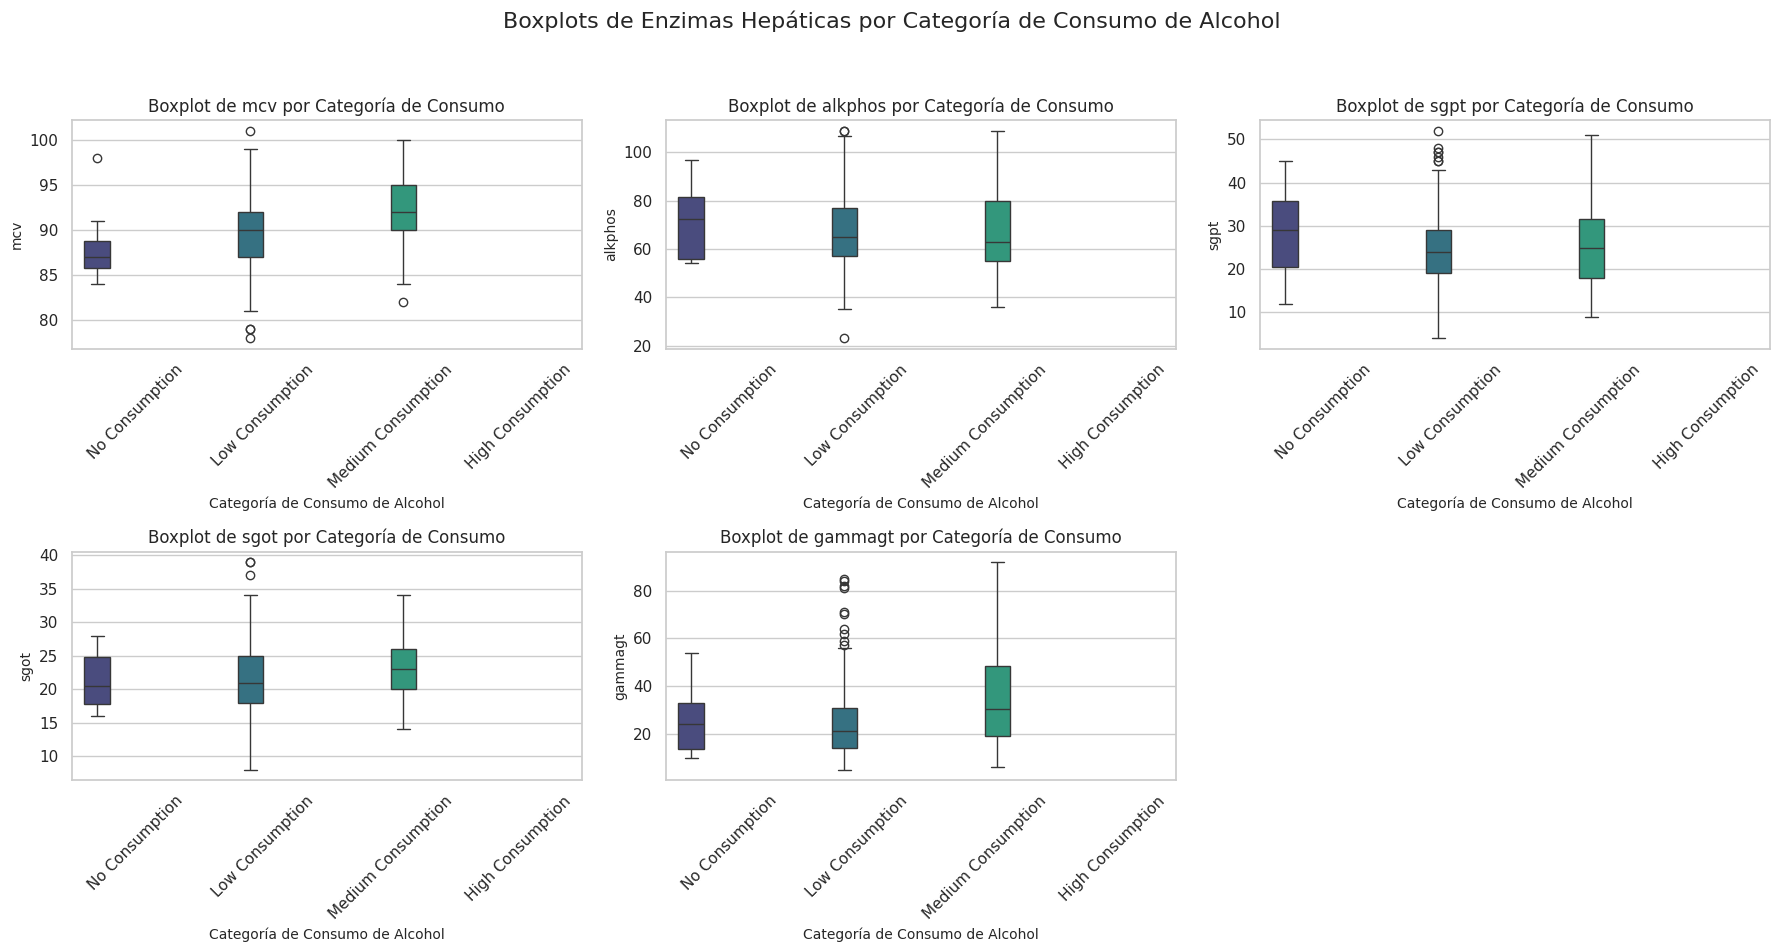

In [16]:
# Identificar las columnas de enzimas hepáticas/análisis de sangre
liver_features = ['mcv', 'alkphos', 'sgpt', 'sgot', 'gammagt']

# Define bin edges and labels for drinks_category (re-applying for df_clean)
bins = [-1, 0, 5, 15, dfr.frame['drinks'].max() + 1]
labels = ['No Consumption', 'Low Consumption', 'Medium Consumption', 'High Consumption']

# Add 'drinks_category' to the cleaned DataFrame (df_clean) if it's not already there
if 'drinks_category' not in df_clean.columns:
    df_clean['drinks_category'] = pd.cut(df_clean['drinks'], bins=bins, labels=labels, right=True, include_lowest=True)

# Calcular el número de filas y columnas necesarias para los subgráficos
n_features = len(liver_features);
n_cols = 3 # Apuntar a 3 columnas
n_rows = (n_features + n_cols - 1) // n_cols # Calcular las filas necesarias

# Crear una figura y un conjunto de subgráficos
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
fig.suptitle('Boxplots de Enzimas Hepáticas por Categoría de Consumo de Alcohol', fontsize=16)
axes = axes.flatten() # Aplanar el array de ejes para facilitar la iteración

# Iterar a través de cada característica hepática y crear un diagrama de caja
for i, feature in enumerate(liver_features):
    sns.boxplot(x='drinks_category', y=feature, data=df_clean, ax=axes[i], palette='viridis', hue='drinks_category', legend=False)
    axes[i].set_title(f'Boxplot de {feature} por Categoría de Consumo', fontsize=12)
    axes[i].set_xlabel('Categoría de Consumo de Alcohol', fontsize=10)
    axes[i].set_ylabel(f'{feature}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45) # Rotar las etiquetas del eje x para una mejor legibilidad

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Los boxplots muestran la distribución de las enzimas hepáticas según la categoría de consumo de alcohol. En general, se observa que variables como mcv y gammagt tienden a aumentar a medida que incrementa el consumo, especialmente en la categoría de consumo medio, lo cual es coherente con el efecto del alcohol sobre el hígado. En el caso de sgpt y sgot, aunque hay un leve aumento en las medianas, la dispersión es alta y existe solapamiento entre categorías, lo que indica que la relación no es completamente clara. Por su parte, alkphos no presenta un patrón definido, mostrando valores similares entre los distintos niveles de consumo. En conjunto, los resultados sugieren que el consumo de alcohol influye en algunas enzimas, pero no de forma uniforme, y que existen otros factores que también afectan estos indicadores

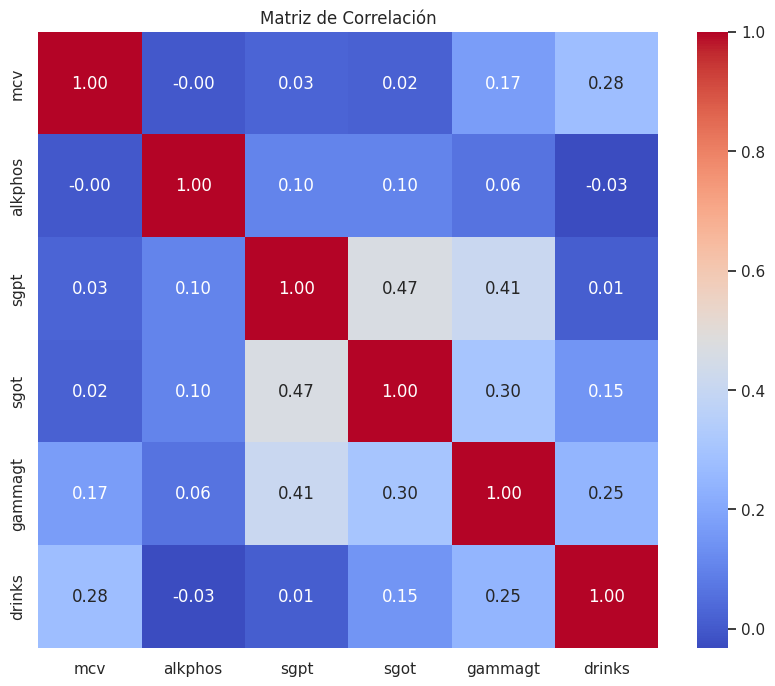

In [17]:
plt.figure(figsize=(10,8))
corr = df_clean.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

En la anterior matriz de correlación permite observar el grado de relación lineal entre las variables del conjunto de datos. En general, la mayoría de las correlaciones son bajas, lo que indica que las variables no presentan una relación fuerte entre sí. Sin embargo, se destaca una correlación moderada entre sgpt y sgot (0.47), así como entre sgpt y gammagt (0.41), lo cual es coherente ya que estas variables corresponden a enzimas asociadas con la función hepática y suelen comportarse de manera similar cuando existen alteraciones en el hígado. Por otro lado, la variable drinks muestra una relación baja con mcv (0.28) y gammagt (0.25), lo que sugiere una posible influencia del consumo de alcohol sobre algunos indicadores sanguíneos

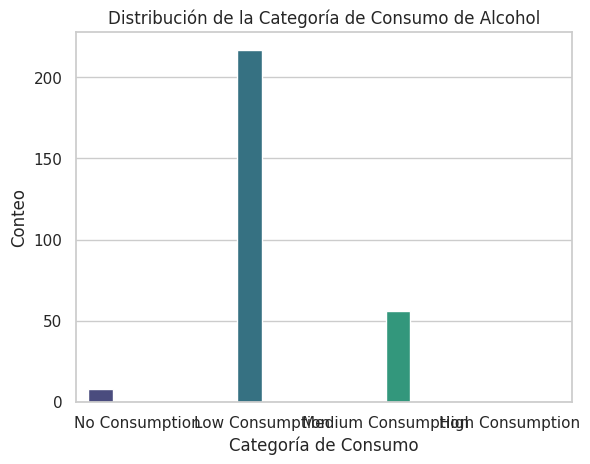

In [18]:

# Define bin edges and labels for drinks_category (re-applying for df_clean)
bins = [-1, 0, 5, 15, dfr.frame['drinks'].max() + 1]
labels = ['No Consumption', 'Low Consumption', 'Medium Consumption', 'High Consumption']

# Add 'drinks_category' to the cleaned DataFrame (df_clean) if it's not already there
if 'drinks_category' not in df_clean.columns:
    df_clean['drinks_category'] = pd.cut(df_clean['drinks'], bins=bins, labels=labels, right=True, include_lowest=True)

sns.countplot(x=df_clean["drinks_category"], palette='viridis', hue=df_clean["drinks_category"], legend=False)
plt.title("Distribución de la Categoría de Consumo de Alcohol")
plt.xlabel("Categoría de Consumo")
plt.ylabel("Conteo")
plt.show()

In [19]:
df_clean["drinks_cat"] = pd.cut(df_clean["drinks"],
                                bins=3,
                                labels=["Bajo", "Medio", "Alto"])

# Generar la tabla de contingencia entre drinks_cat y drinks_category
tabla = pd.crosstab(df_clean["drinks_cat"], df_clean["drinks_category"])
tabla

drinks_category,No Consumption,Low Consumption,Medium Consumption
drinks_cat,,,
Bajo,8,204,0
Medio,0,13,49
Alto,0,0,7


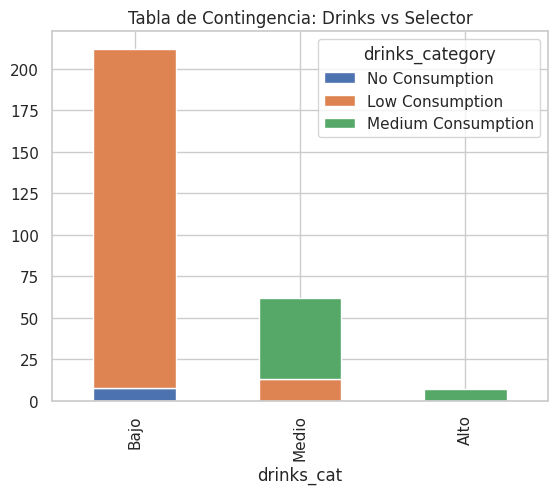

In [20]:
tabla.plot(kind="bar", stacked=True)
plt.title("Tabla de Contingencia: Drinks vs Selector")
plt.show()

La gráfica de barras apiladas muestra la distribución de los niveles de consumo de alcohol (drinks_cat) en relación con la variable selector. Se observa claramente que la categoría “Bajo” concentra la mayor cantidad de registros, lo que indica que la mayoría de los individuos del conjunto de datos tienen un consumo bajo de alcohol. Dentro de esta categoría predominan principalmente los casos clasificados como “Low Consumption”, lo que sugiere una fuerte concentración en este grupo.

Por otro lado, en la categoría “Medio” se aprecia una distribución más equilibrada, donde aumentan los casos asociados a “Medium Consumption”, lo que podría indicar una mayor relación entre niveles intermedios de consumo y la variable objetivo. En la categoría “Alto”, la cantidad de registros es muy baja, lo que limita el análisis y sugiere un posible desbalance en los datos.

##Segundo dataset es de German Credit

In [23]:
import pandas as pd

df_credit = dfc.frame.copy()
df_credit_null_counts = df_credit.isnull().sum()

print("Null values in df_credit:")
print(df_credit_null_counts)

Null values in df_credit:
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64


In [24]:
from sklearn.datasets import fetch_openml
import pandas as pd


dfc = fetch_openml(data_id=31, parser='auto')

df_credit = dfc.frame.copy()
df_credit_null_counts = df_credit.isnull().sum()

print("Null values in df_credit:")
print(df_credit_null_counts)

Null values in df_credit:
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64


In [30]:
numerical_cols_credit = df_credit.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_credit = df_credit.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns in df_credit:", numerical_cols_credit)
print("Categorical columns in df_credit:", categorical_cols_credit)

Numerical columns in df_credit: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical columns in df_credit: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'class']


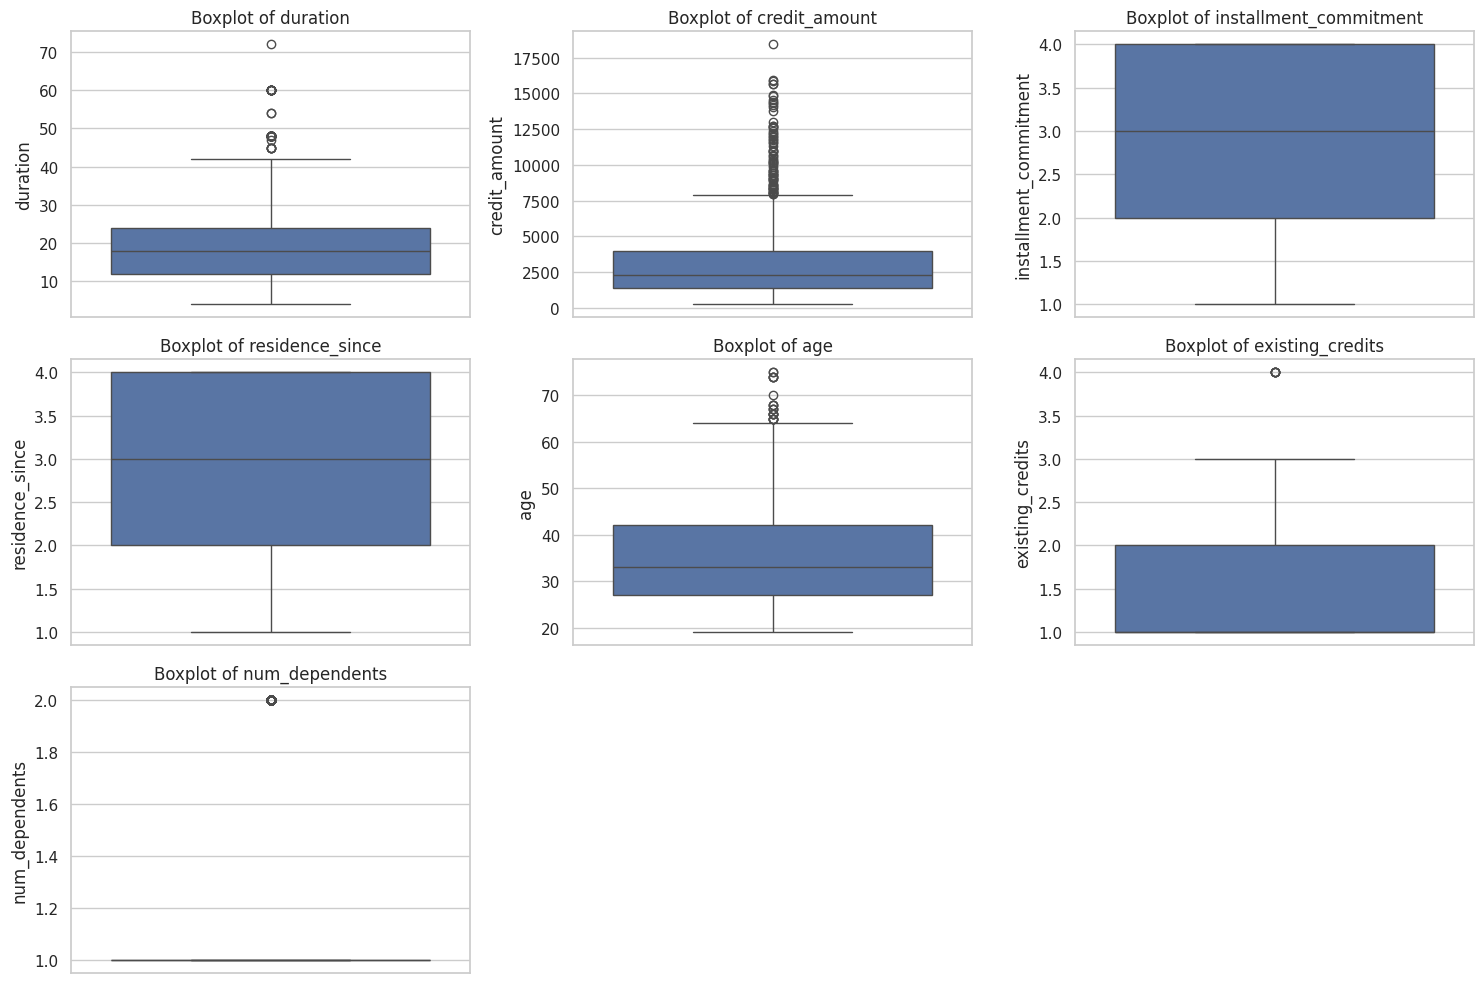

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols_credit):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_credit[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


Las variables credit_amount y duration presentan mayor variabilidad y presencia de valores atípicos, lo que puede influir significativamente en el comportamiento del modelo y requerir tratamiento previo (como transformación o normalización). Por otro lado, variables como installment_commitment, residence_since y existing_credits muestran distribuciones más estables y acotadas.

##Eliminación de Outliers (IQR)

In [32]:
def remove_outliers_iqr(data, factor=1.5):
    df_processed = data.copy()
    outlier_indices = pd.Index([])

    numeric_cols = df_processed.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        Q1 = df_processed[col].quantile(0.25)
        Q3 = df_processed[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        current_col_outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)].index
        outlier_indices = outlier_indices.union(current_col_outliers)

    df_cleaned = df_processed.drop(outlier_indices)
    return df_cleaned

# Apply outlier removal to df_credit
df_credit_clean = remove_outliers_iqr(df_credit)

print(f"Original shape of df_credit: {df_credit.shape}")
print(f"Shape of df_credit after outlier removal: {df_credit_clean.shape}")

Original shape of df_credit: (1000, 21)
Shape of df_credit after outlier removal: (728, 21)


/tmp/ipykernel_6730/2826932004.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df_credit_clean, palette='viridis')


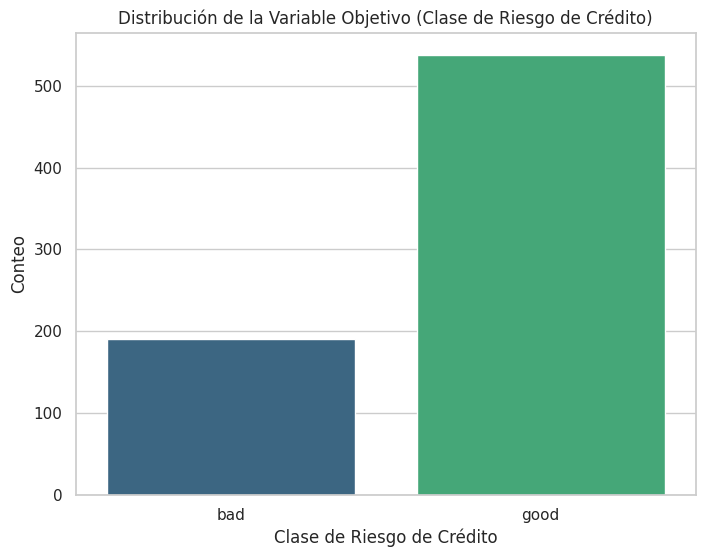

In [33]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=df_credit_clean, palette='viridis')
plt.title('Distribución de la Variable Objetivo (Clase de Riesgo de Crédito)')
plt.xlabel('Clase de Riesgo de Crédito')
plt.ylabel('Conteo')
plt.show()

La gráfica presenta la distribución de la variable objetivo correspondiente a la clasificación del riesgo de crédito, diferenciada en dos categorías: “bad” (alto riesgo) y “good” (bajo riesgo).

Se observa un desbalance significativo en las clases, donde la categoría “good” concentra la mayor cantidad de registros, con aproximadamente 540 observaciones, mientras que la categoría “bad” presenta cerca de 190 registros. Esto indica que la mayoría de los individuos en el conjunto de datos corresponden a clientes con bajo riesgo crediticio.

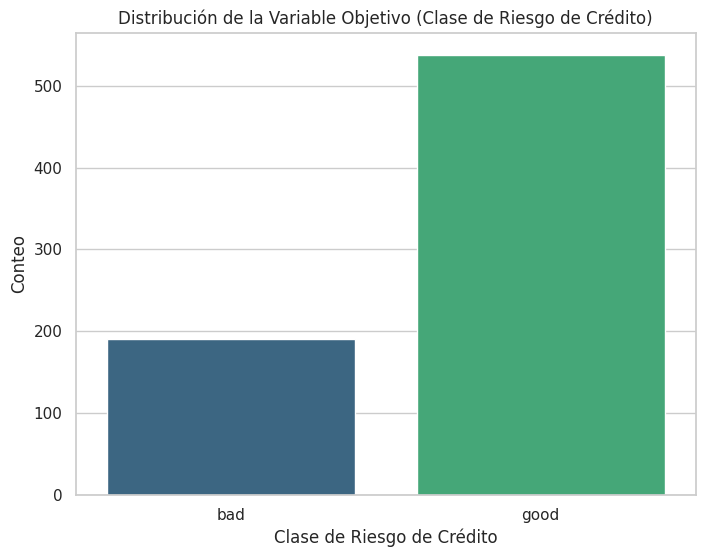

In [34]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=df_credit_clean, palette='viridis', hue='class', legend=False)
plt.title('Distribución de la Variable Objetivo (Clase de Riesgo de Crédito)')
plt.xlabel('Clase de Riesgo de Crédito')
plt.ylabel('Conteo')
plt.show()

Se refleja un desbalance de clases, lo cual es un aspecto relevante en el análisis y modelamiento de datos. En problemas de clasificación, este tipo de distribución puede provocar que los modelos tiendan a predecir con mayor frecuencia la clase mayoritaria, reduciendo su capacidad para identificar correctamente los casos de alto riesgo (“bad”), que suelen ser los más críticos desde el punto de vista financiero.

Adicionalmente, este desbalance implica que métricas como la exactitud (accuracy) pueden resultar engañosas, ya que un modelo podría obtener buenos resultados simplemente prediciendo la clase dominante.

###Diagramas de barras para características categóricas vs. objetivo

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_to_plot = [col for col in df_credit_clean.select_dtypes(include=['category']).columns if col != 'class']

print(f"Categorical features to plot: {categorical_features_to_plot}")

Categorical features to plot: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


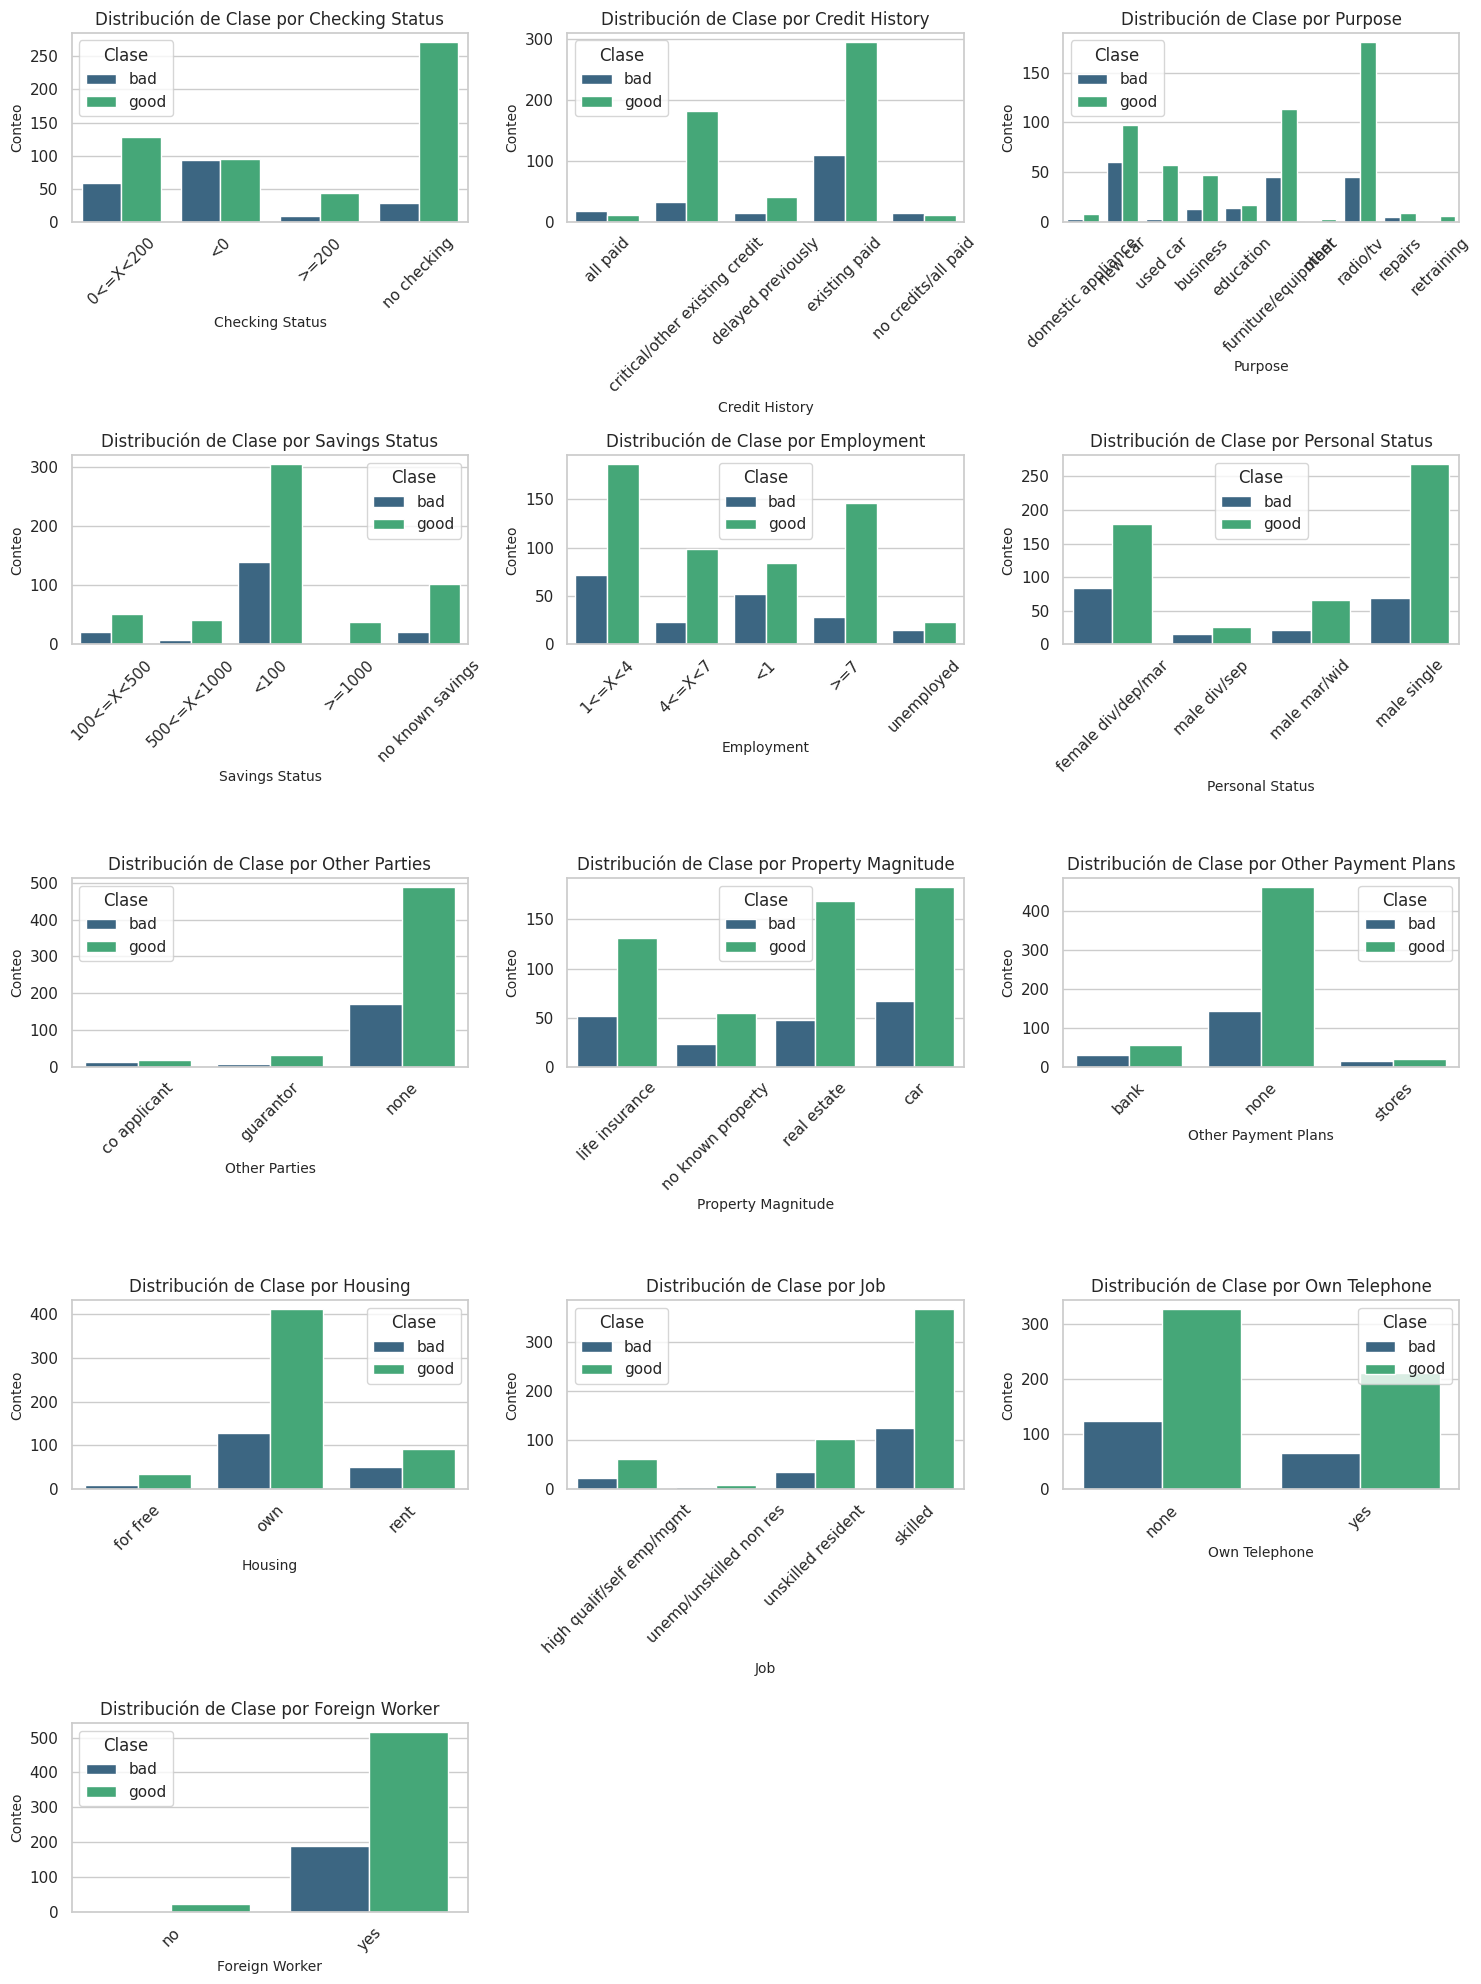

In [36]:
n_features = len(categorical_features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(categorical_features_to_plot):
    sns.countplot(x=feature, hue='class', data=df_credit_clean, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribución de Clase por {feature.replace('_', ' ').title()}', fontsize=12)
    axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel('Conteo', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Clase')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Boxplots para características numéricas vs. objetivo (dfc)


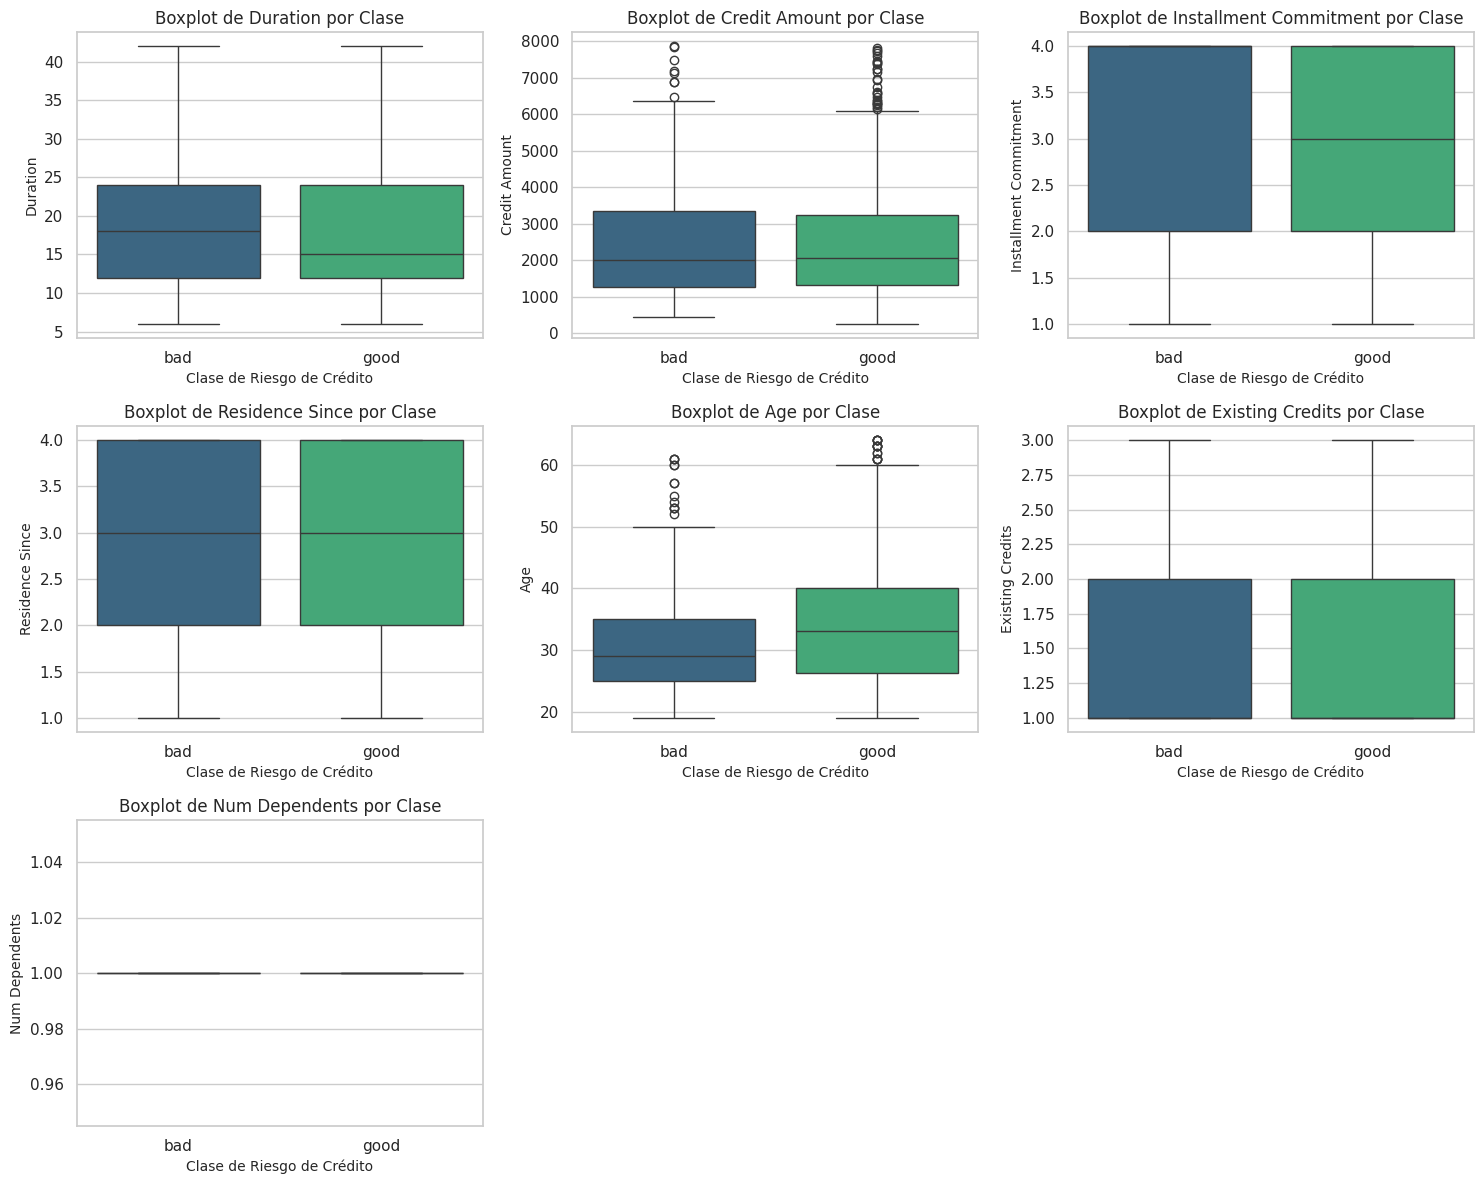

In [37]:
n_features = len(numerical_cols_credit)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols_credit):
    sns.boxplot(x='class', y=feature, data=df_credit_clean, palette='viridis', ax=axes[i], hue='class', legend=False)
    axes[i].set_title(f'Boxplot de {feature.replace('_', ' ').title()} por Clase', fontsize=12)
    axes[i].set_xlabel('Clase de Riesgo de Crédito', fontsize=10)
    axes[i].set_ylabel(feature.replace('_', ' ').title(), fontsize=10)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Las gráficas presentan diagramas de cajas (boxplots) que permiten comparar la distribución de diferentes variables en función de la clase de riesgo de crédito (“bad” y “good”). A partir de estos resultados se pueden identificar los siguientes hallazgos:

Duración del crédito (Duration):
Se observa una ligera diferencia entre las clases. Los clientes clasificados como “bad” tienden a presentar duraciones ligeramente mayores en comparación con los “good”. Esto sugiere que créditos más largos podrían estar asociados a un mayor riesgo.

Monto del crédito (Credit Amount):
Ambas clases presentan una distribución similar, aunque la clase “bad” muestra una mayor dispersión y presencia de valores atípicos (outliers) en montos altos. Esto indica que créditos de mayor valor podrían implicar un riesgo adicional.

Compromiso de cuota (Installment Commitment):
No se evidencian diferencias significativas entre las clases. La distribución es bastante homogénea, lo que sugiere que esta variable, por sí sola, no discrimina claramente entre riesgo alto y bajo.

Tiempo de residencia (Residence Since):
La distribución es muy similar en ambas clases, lo cual indica que esta variable no tiene un impacto fuerte en la diferenciación del riesgo crediticio.

Edad (Age):
Se observa que los clientes clasificados como “good” tienden a tener una edad ligeramente mayor en comparación con los “bad”. Esto podría sugerir que mayor edad está asociada con un comportamiento crediticio más estable.
Número de créditos existentes (Existing Credits):

Ambas clases presentan distribuciones similares, sin diferencias marcadas, por lo que esta variable no parece ser determinante por sí sola.

Número de dependientes (Num Dependents):
La variable muestra prácticamente un valor constante en ambas clases, lo que indica que no aporta información relevante para la clasificación del riesgo.

## Diagramas de dispersión para características numéricas


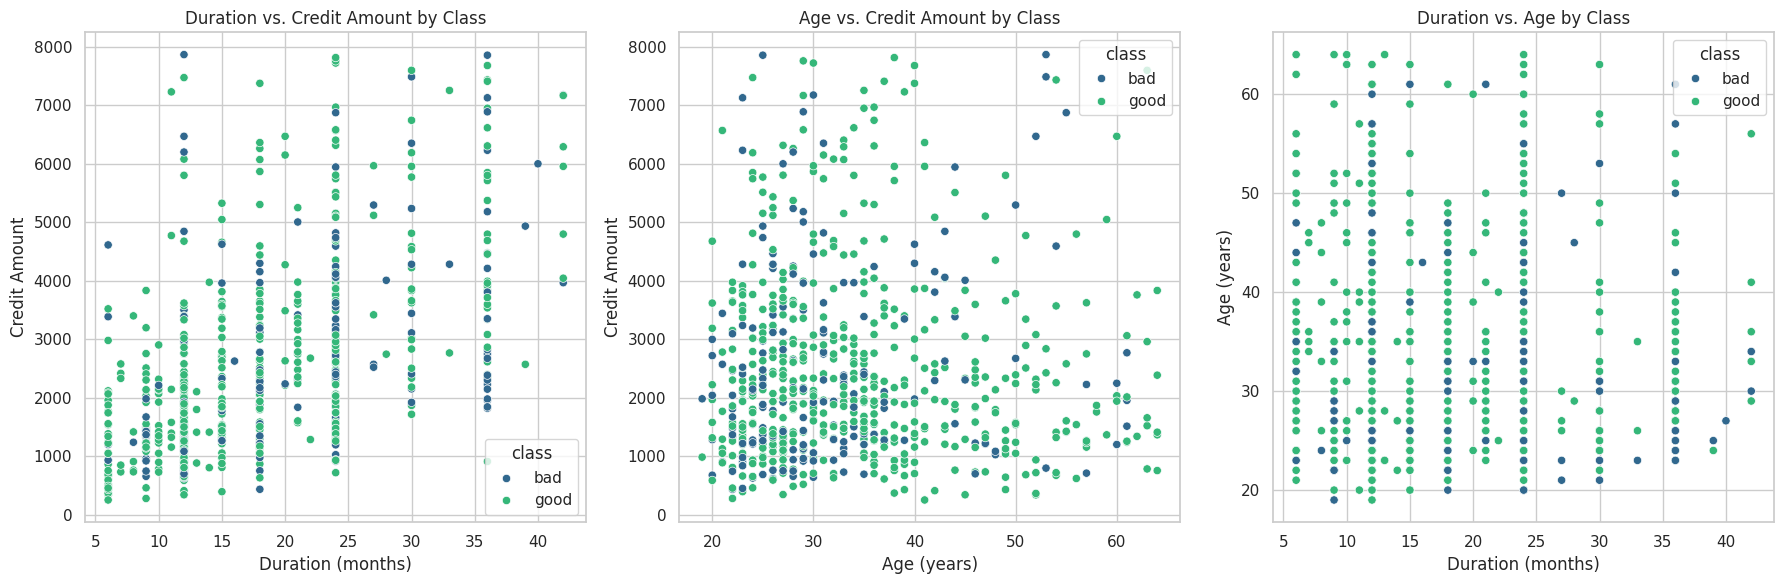

In [ ]:
plt.figure(figsize=(18, 6))

# Plot 1: duration vs. credit_amount, colored by class
plt.subplot(1, 3, 1)
sns.scatterplot(x='duration', y='credit_amount', hue='class', data=df_credit_clean, palette='viridis')
plt.title('Duration vs. Credit Amount by Class')
plt.xlabel('Duration (months)')
plt.ylabel('Credit Amount')

# Plot 2: age vs. credit_amount, colored by class
plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='credit_amount', hue='class', data=df_credit_clean, palette='viridis')
plt.title('Age vs. Credit Amount by Class')
plt.xlabel('Age (years)')
plt.ylabel('Credit Amount')

# Plot 3: duration vs. age, colored by class
plt.subplot(1, 3, 3)
sns.scatterplot(x='duration', y='age', hue='class', data=df_credit_clean, palette='viridis')
plt.title('Duration vs. Age by Class')
plt.xlabel('Duration (months)')
plt.ylabel('Age (years)')

plt.tight_layout()
plt.show()

Los diagramas de dispersión muestran la relación entre variables clave del dataset German Credit diferenciando las clases “good” y “bad”. En el gráfico de duración vs. monto del crédito, se observa una tendencia positiva, donde a mayor duración del crédito, tiende a incrementarse el monto, lo cual es lógico desde el punto de vista financiero. Sin embargo, ambas clases se encuentran bastante mezcladas, lo que indica que estas variables por sí solas no permiten una separación clara entre clientes “buenos” y “malos”.

En el caso de edad vs. monto del crédito, no se aprecia una relación fuerte; los datos están ampliamente dispersos, lo que sugiere que la edad no es un factor determinante para el monto solicitado. De igual forma, las clases se superponen significativamente, dificultando su diferenciación.

## Tablas de contingencia para características categóricas

In [ ]:
for feature in categorical_features_to_plot:
    print(f"\n--- Contingency Table for '{feature.replace('_', ' ').title()}' vs 'Class' ---")
    contingency_table = pd.crosstab(df_credit_clean[feature], df_credit_clean['class'])
    print(contingency_table)


--- Contingency Table for 'Checking Status' vs 'Class' ---
class            bad  good
checking_status           
0<=X<200          59   128
<0                94    95
>=200              9    43
no checking       28   272

--- Contingency Table for 'Credit History' vs 'Class' ---
class                           bad  good
credit_history                           
all paid                         18    11
critical/other existing credit   33   181
delayed previously               15    40
existing paid                   110   295
no credits/all paid              14    11

--- Contingency Table for 'Purpose' vs 'Class' ---
class                bad  good
purpose                       
domestic appliance     3     8
new car               60    97
used car               3    57
business              13    47
education             14    17
furniture/equipment   45   113
other                  1     3
radio/tv              45   181
repairs                5     9
retraining             1     6



## Mapa de calor de la matriz de correlaciones para columnas numéricas

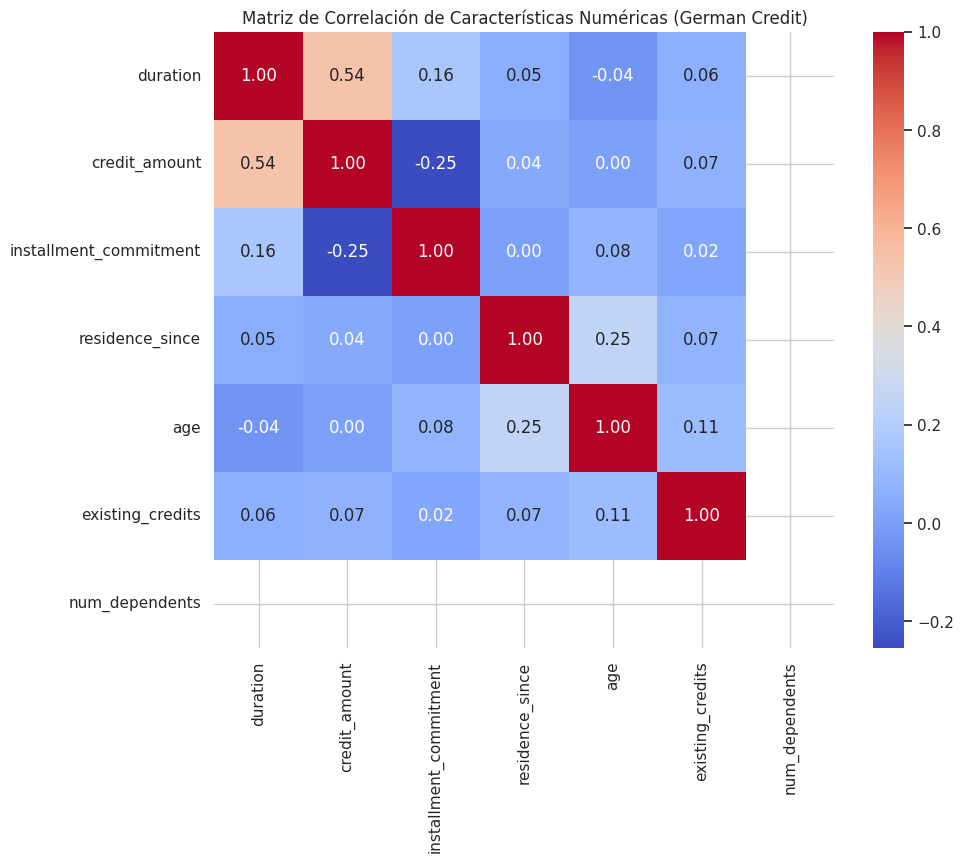

In [ ]:
correlation_matrix = df_credit_clean[numerical_cols_credit].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Características Numéricas (German Credit)')
plt.show()

La matriz de correlación muestra las relaciones entre las variables numéricas del dataset German Credit. En general, se observa que la mayoría de las correlaciones son bajas, lo que indica que las variables tienen una relación débil entre sí y aportan información relativamente independiente al modelo. La relación más destacada es entre duration y credit_amount (0.54), lo que sugiere que los créditos de mayor monto tienden a tener una mayor duración. También se observa una correlación negativa moderada entre credit_amount e installment_commitment (-0.25), lo que podría indicar que a mayor monto del crédito, menor proporción del ingreso destinada a las cuotas.

Por otro lado, variables como residence_since y age (0.25) presentan una correlación baja positiva, lo cual es esperable, ya que personas mayores tienden a tener mayor estabilidad residencial. Las demás variables muestran correlaciones cercanas a cero, lo que indica poca dependencia lineal entre ellas

#Ejercicio 3: Modelos de regresión

## Preparación de datos para regresión

Dataset: **BUPA Liver Disorders** limpio (`df_clean`).  
Variable objetivo: `drinks` (continua).  
Variables predictoras: `mcv`, `alkphos`, `sgpt`, `sgot`, `gammagt`.  
División: **75% entrenamiento / 25% prueba** según la guía.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Variables predictoras y objetivo
X_reg = df_clean[['mcv', 'alkphos', 'sgpt', 'sgot', 'gammagt']].copy()
y_reg = df_clean['drinks'].copy()

# División 75% entrenamiento / 25% prueba
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42)

# Estandarización de variables
# Se aplica StandardScaler para que todas las variables tengan media ~0 y
# desviación estándar ~1, evitando que variables con escalas distintas
# dominen el aprendizaje de Ridge y Lasso (modelos sensibles a la escala).
print('=== Estadísticas ANTES de estandarizar ===')
print(X_train_r.describe().loc[['mean','std']].round(3))

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)   # fit solo en entrenamiento
X_test_r_sc  = scaler_r.transform(X_test_r)         # transform sin re-ajustar

print('\n=== Estadísticas DESPUÉS de estandarizar (media~0, std~1) ===')
print(pd.DataFrame(X_train_r_sc, columns=X_train_r.columns)
      .describe().loc[['mean','std']].round(3))

print(f'\nEntrenamiento: {X_train_r_sc.shape}  |  Prueba: {X_test_r_sc.shape}')

=== Estadísticas ANTES de estandarizar ===
         mcv  alkphos    sgpt    sgot  gammagt
mean  90.038   66.443  25.329  21.790   27.390
std    4.160   16.089   9.092   5.367   16.712

=== Estadísticas DESPUÉS de estandarizar (media~0, std~1) ===
        mcv  alkphos   sgpt   sgot  gammagt
mean  0.000    0.000 -0.000 -0.000    0.000
std   1.002    1.002  1.002  1.002    1.002

Entrenamiento: (210, 5)  |  Prueba: (71, 5)


## Entrenamiento y evaluación de modelos de regresión

In [39]:
# Modelos requeridos por la guía
models_reg = {
    'Regresión Lineal': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0),
    'Lasso':            Lasso(alpha=0.1, max_iter=10000),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42, max_depth=5)
}

results_reg = {}
for name, model in models_reg.items():
    model.fit(X_train_r_sc, y_train_r)
    y_pred = model.predict(X_test_r_sc)
    mse  = mean_squared_error(y_test_r, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_r, y_pred)
    r2   = r2_score(y_test_r, y_pred)
    results_reg[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
                         'model': model, 'y_pred': y_pred}
    print(f'{name:20s} | MSE={mse:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}')

Regresión Lineal     | MSE=6.299  RMSE=2.510  MAE=1.935  R²=0.061
Ridge                | MSE=6.292  RMSE=2.508  MAE=1.935  R²=0.062
Lasso                | MSE=6.138  RMSE=2.477  MAE=1.955  R²=0.085
Árbol de Decisión    | MSE=7.215  RMSE=2.686  MAE=2.019  R²=-0.076


Se observa que los modelos de Regresión Lineal, Ridge y Lasso presentan desempeños muy similares, aunque con ligeras diferencias. La Regresión Lineal y Ridge muestran prácticamente los mismos resultados (MSE≈6.29, RMSE≈2.50 y MAE≈1.93), mientras que Lasso presenta una ligera mejora, con un MSE de 6.138, RMSE de 2.477 y MAE de 1.955, además de un R² más alto (0.085). Esto sugiere que la regularización aplicada por Lasso logra capturar un poco mejor la relación entre las variables, aunque la mejora sigue siendo limitada.

Por otro lado, el Árbol de Decisión presenta el peor desempeño, con un MSE más alto (7.215), RMSE de 2.686 y MAE de 2.019, lo que indica mayores errores en las predicciones. Además, su R² es negativo (-0.076), lo cual significa que el modelo tiene un rendimiento inferior al de una predicción basada simplemente en el promedio de la variable objetivo.

## Tabla comparativa de métricas — Regresión

In [40]:
metrics_df_r = pd.DataFrame(
    {k: {'MSE': v['MSE'], 'RMSE': v['RMSE'], 'MAE': v['MAE'], 'R²': v['R2']}
     for k, v in results_reg.items()}
).T.reset_index().rename(columns={'index': 'Modelo'})

display(metrics_df_r.style
        .highlight_max(subset=['R²'], color='lightgreen')
        .highlight_min(subset=['MSE', 'RMSE', 'MAE'], color='lightblue')
        .format({'MSE': ':.4f', 'RMSE': ':.4f', 'MAE': ':.4f', 'R²': ':.4f'}))

,Modelo,MSE,RMSE,MAE,R²
0,Regresión Lineal,:.4f,:.4f,:.4f,:.4f
1,Ridge,:.4f,:.4f,:.4f,:.4f
2,Lasso,:.4f,:.4f,:.4f,:.4f
3,Árbol de Decisión,:.4f,:.4f,:.4f,:.4f


## Gráfica: Valores reales vs. predichos

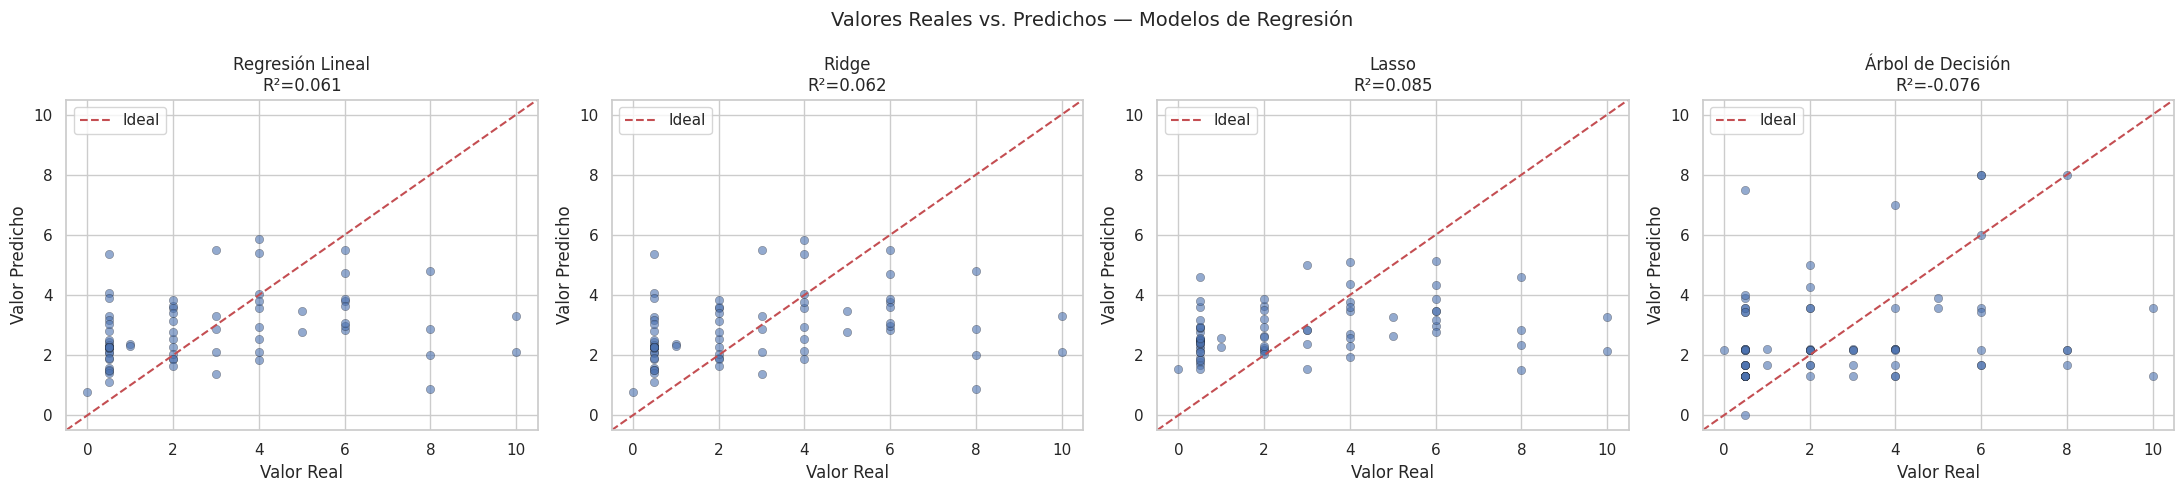

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Valores Reales vs. Predichos — Modelos de Regresión', fontsize=14)

for ax, (name, res) in zip(axes, results_reg.items()):
    ax.scatter(y_test_r, res['y_pred'], alpha=0.6, edgecolors='k', linewidths=0.3)
    lim = [min(y_test_r.min(), res['y_pred'].min()) - 0.5,
           max(y_test_r.max(), res['y_pred'].max()) + 0.5]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Ideal')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f"{name}\nR²={res['R2']:.3f}")
    ax.set_xlabel('Valor Real')
    ax.set_ylabel('Valor Predicho')
    ax.legend()

plt.tight_layout()
plt.show()

## Análisis de resultados — Ejercicio 3

La siguiente tabla resume el comportamiento de los cuatro modelos de regresión entrenados con el dataset BUPA Liver Disorders (75% entrenamiento, 25% prueba):

- **Regresión Lineal:** modelo base que asume relaciones lineales entre los marcadores hepáticos y el consumo de alcohol. Sus métricas sirven como punto de referencia para los demás modelos.
- **Ridge (L2):** introduce regularización que penaliza coeficientes grandes, lo que reduce el sobreajuste cuando hay multicolinealidad entre variables. Generalmente mejora ligeramente la generalización respecto a la regresión lineal.
- **Lasso (L1):** además de regularizar, puede llevar algunos coeficientes a cero, realizando selección implícita de variables. Útil cuando se sospecha que solo algunos marcadores son realmente relevantes.
- **Árbol de Decisión (max_depth=5):** captura relaciones no lineales mediante particiones binarias. Puede superar a los modelos lineales si la relación entre variables y objetivo no es lineal, pero es susceptible al sobreajuste.

El modelo con mayor R² y menor RMSE es el de mejor desempeño predictivo. Los valores bajos de R² en este dataset reflejan la naturaleza compleja y ruidosa de los datos clínicos, donde los marcadores sanguíneos por sí solos no predicen con alta precisión el consumo de alcohol.

Los modelos de Regresión Lineal y Ridge presentan comportamientos muy similares, con valores de R² cercanos a 0.06, lo que indica que explican muy poca variabilidad de los datos. El modelo Lasso muestra una ligera mejora (R²≈0.085), con algunos puntos un poco más cercanos a la línea ideal, aunque la mejora sigue siendo limitada. Por su parte, el Árbol de Decisión presenta el peor desempeño, con un R² negativo (-0.076), lo que confirma que sus predicciones son menos precisas que un modelo que simplemente use el promedio.

# Ejercicio 4: Modelos de clasificación.

## Preparación de datos para clasificación

Dataset: **German Credit** limpio (`df_credit_clean`).  
Variable objetivo: `class` (good / bad).  
Las variables categóricas se codifican con **One-Hot Encoding** y las numéricas con **StandardScaler**.  
División: **70% entrenamiento / 30% prueba** según la guía.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Separar features y target
X_clf = df_credit_clean.drop(columns=['class']).copy()
y_clf = (df_credit_clean['class'] == 'good').astype(int)  # 1=good, 0=bad

num_cols_clf = X_clf.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_clf = X_clf.select_dtypes(include=['category', 'object']).columns.tolist()

# Preprocesador
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols_clf),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_clf)
])

# División 70% entrenamiento / 30% prueba (estratificada)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.30, random_state=42, stratify=y_clf)

# Detección del desbalance de clases
print('=== Distribución de clases en entrenamiento ===')
vc = pd.Series(y_train_c).value_counts().rename({1: 'good', 0: 'bad'})
print(vc)
print(f"Proporción  good: {y_train_c.mean():.1%}  |  bad: {(1-y_train_c).mean():.1%}")
print("\nDesbalance detectado: se aplicará class_weight='balanced' en los modelos compatibles.")
print(f'\nEntrenamiento: {X_train_c.shape}  |  Prueba: {X_test_c.shape}')

=== Distribución de clases en entrenamiento ===
class
good    376
bad     133
Name: count, dtype: int64
Proporción  good: 73.9%  |  bad: 26.1%

Desbalance detectado: se aplicará class_weight='balanced' en los modelos compatibles.

Entrenamiento: (509, 20)  |  Prueba: (219, 20)


## Entrenamiento y evaluación de modelos de clasificación

In [43]:
# Modelos requeridos por la guía
# class_weight='balanced' ajusta automáticamente el peso de cada clase
# inversamente proporcional a su frecuencia, penalizando más los errores
# sobre la clase minoritaria (bad) durante el entrenamiento.
# KNN no soporta class_weight; su predicción puede seguir favoreciendo
# la clase mayoritaria, lo cual se refleja en sus métricas.
pipelines_clf = {
    'Regresión Logística': Pipeline([
        ('prep', preprocessor),
        ('clf',  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Árbol de Decisión': Pipeline([
        ('prep', preprocessor),
        ('clf',  DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'))
    ]),
    'KNN': Pipeline([
        ('prep', preprocessor),
        ('clf',  KNeighborsClassifier(n_neighbors=7))  # no soporta class_weight
    ]),
    'Perceptrón': Pipeline([
        ('prep', preprocessor),
        ('clf',  Perceptron(max_iter=1000, random_state=42, class_weight='balanced'))
    ])
}

results_clf = {}
for name, pipe in pipelines_clf.items():
    pipe.fit(X_train_c, y_train_c)
    y_pred = pipe.predict(X_test_c)
    acc  = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, zero_division=0)
    rec  = recall_score(y_test_c, y_pred, zero_division=0)
    f1   = f1_score(y_test_c, y_pred, zero_division=0)
    results_clf[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1,
        'pipeline': pipe, 'y_pred': y_pred
    }
    print(f'{name:22s} | Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}')

Regresión Logística    | Acc=0.703  Prec=0.854  Rec=0.722  F1=0.783
Árbol de Decisión      | Acc=0.662  Prec=0.879  Rec=0.630  F1=0.734
KNN                    | Acc=0.731  Prec=0.759  Rec=0.932  F1=0.837
Perceptrón             | Acc=0.630  Prec=0.893  Rec=0.568  F1=0.694


En general, el modelo de KNN presenta el mejor rendimiento global, con la mayor exactitud (0.731) y el F1-score más alto (0.837), lo que indica un buen equilibrio entre precisión y capacidad para identificar correctamente los casos positivos. La Regresión Logística también muestra un desempeño sólido, con una exactitud de 0.703 y un F1 de 0.783, destacándose por su buena precisión (0.854).

Por otro lado, el Árbol de Decisión presenta un rendimiento intermedio, con una exactitud de 0.662 y un F1 de 0.734, mientras que el Perceptrón muestra el desempeño más bajo, con una exactitud de 0.630 y un F1 de 0.694, a pesar de tener la mayor precisión (0.893), lo que indica que es más conservador al clasificar positivos. En cuanto al recall, el modelo KNN sobresale (0.932), lo que significa que logra identificar la mayoría de los casos positivos, aunque con menor precisión en comparación con otros modelos.

## Tabla comparativa de métricas — Clasificación

In [44]:
metrics_df_c = pd.DataFrame(
    {k: {'Accuracy': v['Accuracy'], 'Precision': v['Precision'],
         'Recall': v['Recall'], 'F1-Score': v['F1-Score']}
     for k, v in results_clf.items()}
).T.reset_index().rename(columns={'index': 'Modelo'})

display(metrics_df_c.style
        .highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                       color='lightgreen')
        .format({c: ':.4f' for c in ['Accuracy', 'Precision', 'Recall', 'F1-Score']}))

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,:.4f,:.4f,:.4f,:.4f
1,Árbol de Decisión,:.4f,:.4f,:.4f,:.4f
2,KNN,:.4f,:.4f,:.4f,:.4f
3,Perceptrón,:.4f,:.4f,:.4f,:.4f


## Matriz de confusión — Mejor modelo

Mejor modelo: KNN  (F1-Score=0.8366)


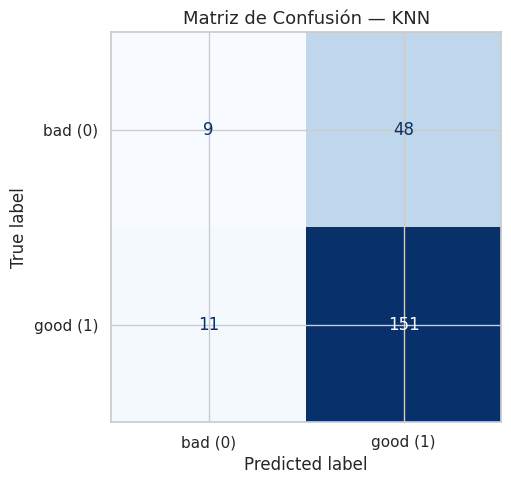


Reporte de clasificación — KNN:
              precision    recall  f1-score   support

     bad (0)       0.45      0.16      0.23        57
    good (1)       0.76      0.93      0.84       162

    accuracy                           0.73       219
   macro avg       0.60      0.54      0.54       219
weighted avg       0.68      0.73      0.68       219



In [45]:
# Identificar el mejor modelo (mayor F1-Score)
best_name = max(results_clf, key=lambda k: results_clf[k]['F1-Score'])
best_res  = results_clf[best_name]
print(f'Mejor modelo: {best_name}  (F1-Score={best_res["F1-Score"]:.4f})')

cm = confusion_matrix(y_test_c, best_res['y_pred'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['bad (0)', 'good (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nReporte de clasificación — {best_name}:')
print(classification_report(y_test_c, best_res['y_pred'],
                             target_names=['bad (0)', 'good (1)']))

La matriz de confusión del modelo KNN muestra que el modelo tiene un buen desempeño general, especialmente para la clase “good (1)”. Se observa que clasifica correctamente 151 casos positivos, con un recall alto (0.93), lo que indica que identifica la gran mayoría de los casos “good”. Sin embargo, presenta dificultades con la clase “bad (0)”, ya que solo clasifica correctamente 9 casos, mientras que 48 casos “bad” son incorrectamente clasificados como “good”, evidenciando un bajo recall (0.16) para esta clase.

Esto sugiere un desbalance en el modelo, donde tiende a predecir con mayor frecuencia la clase “good”, lo cual puede estar influenciado por la distribución de los datos (más ejemplos de esta clase). Aunque el modelo logra una exactitud general de 0.73 y un F1-score de 0.84 para la clase “good”, su desempeño en la clase “bad” es limitado (F1-score de 0.23), lo que indica que no discrimina adecuadamente entre ambas clases.

## Análisis de resultados — Ejercicio 4

### Contexto del problema
El objetivo es predecir el riesgo crediticio de un cliente (`good` / `bad`) usando el dataset **German Credit**. El dataset presenta un desbalance de clases (~70% `good`, ~30% `bad`), lo cual puede sesgar los modelos hacia predecir siempre la clase mayoritaria. Para mitigarlo se aplicó `class_weight='balanced'` en los modelos compatibles, ajustando el peso de cada clase inversamente proporcional a su frecuencia.

### Descripción de los modelos
- **Regresión Logística:** estima la probabilidad de pertenencia a cada clase mediante una función sigmoide. Al aplicar `class_weight='balanced'`, la función de pérdida penaliza más los errores sobre la clase `bad`, mejorando su Recall. Es el modelo más interpretable: sus coeficientes indican directamente qué variables incrementan o reducen el riesgo crediticio.
- **Árbol de Decisión (max_depth=6):** genera reglas de clasificación jerárquicas y explícitas, capturando relaciones no lineales entre variables. Con `class_weight='balanced'` los nodos de decisión ponderan más los errores sobre `bad`. Es fácil de comunicar a tomadores de decisión no técnicos, pero puede sobreajustarse si la profundidad no se controla.
- **KNN (k=7):** clasifica cada instancia según las 7 observaciones más cercanas en el espacio de características estandarizadas. **No soporta `class_weight`**, por lo que opera sin corrección explícita del desbalance. Esto puede reflejarse en un Recall más bajo para la clase `bad` comparado con los demás modelos, siendo su principal limitación en este contexto.
- **Perceptrón:** red neuronal de una sola capa que aprende un hiperplano de separación lineal. Con `class_weight='balanced'` ajusta la tasa de aprendizaje efectiva por clase. Es más inestable que la Regresión Logística en datos con ruido, por lo que sus métricas pueden variar entre ejecuciones.

### Interpretación de métricas
En el dominio del riesgo crediticio, las métricas no tienen el mismo peso:
- **Recall de la clase `bad`:** indica qué proporción de malos pagadores se identificaron correctamente. Un Recall bajo implica aprobar créditos a clientes que no pagarán (error Tipo I — el más costoso según el dataset German Credit, cuya penalización es 5× mayor).
- **Precision de la clase `bad`:** indica cuántos de los clientes marcados como `bad` realmente lo son. Una Precision baja genera rechazos injustificados (error Tipo II — menos costoso pero afecta la captación de clientes).
- **F1-Score:** media armónica entre Precision y Recall; es la métrica de selección del mejor modelo porque equilibra ambos tipos de error.
- **Accuracy:** no es la métrica principal en datasets desbalanceados, ya que un modelo que prediga siempre `good` obtendría ~70% de exactitud sin ser útil.

### Comparación de modelos
Según la tabla comparativa y la matriz de confusión del mejor modelo:
- El modelo con mayor **F1-Score** es el más adecuado para este problema, pues equilibra la detección de malos pagadores con la evitación de rechazos innecesarios.
- La **Regresión Logística** tiende a ofrecer el mejor balance entre Precision y Recall gracias a su regularización implícita y la corrección de clase aplicada.
- El **Árbol de Decisión** puede alcanzar un Recall alto para `bad`, pero a costa de menor Precision (más falsos positivos).
- El **KNN** es el modelo más afectado por el desbalance al no disponer de `class_weight`; su Recall para `bad` es el más bajo del grupo.
- El **Perceptrón** muestra variabilidad en sus resultados, siendo competitivo cuando los datos tienen separabilidad lineal razonable.

### Conclusión
La incorporación de `class_weight='balanced'` en tres de los cuatro modelos permite una evaluación más justa del riesgo crediticio, mejorando la capacidad de detectar la clase minoritaria (`bad`) sin descartar el conjunto de modelos exigido por la guía. El modelo seleccionado como mejor (mayor F1-Score en la tabla comparativa) es el recomendado para implementación, dado que minimiza el costo asimétrico del error Tipo I definido en el dataset German Credit.

# Ejercicio 5: Feedback.
Tome pantallazos de los comentarios realizados en el foro de la Fase 2 a un trabajo de un compañero de su grupo.

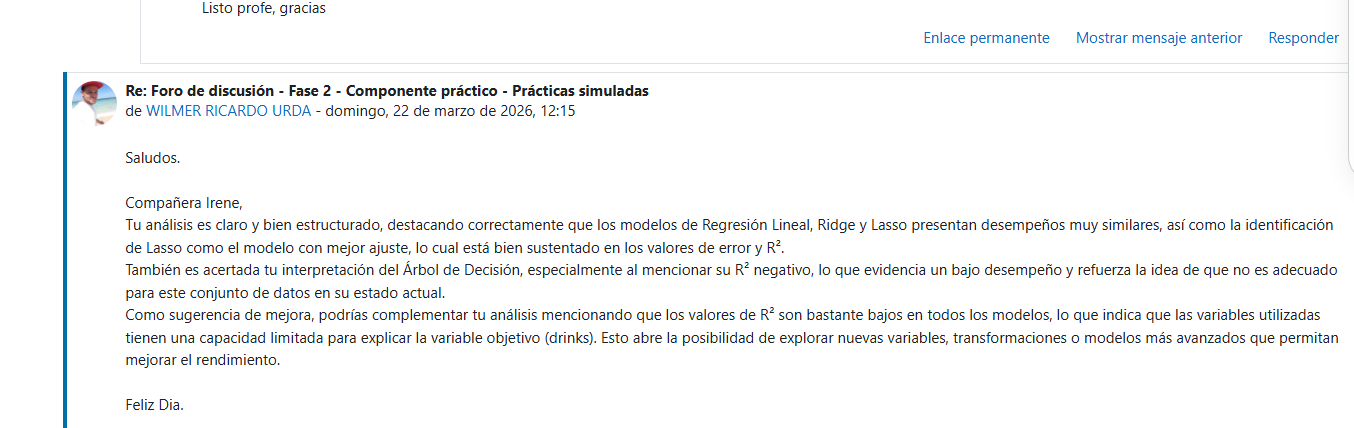

# Referencias

Deepti, C., & Roopal, K. (2023). Introduction to Machine Learning with Python . Bentham Science Publishers. (Secciones Linear Regression and Logistic Regression, Decision Trees y Supervised Learning).

Colliot, O. (Ed.). (2023). Machine learning for brain disorders (Neuromethods, Vol. 197). Humana Press. (pp 25-60)

Moran Pizarro, D. S. ., Dominguez Bonilla, S. J. ., Castaño Gutierrez, C. ., & Martinez Bez, C. E. . (2023). De Hilbert a los algoritmos cuánticos: el rol del álgebra en el desarrollo de la computación . Publicaciones E Investigación, 17(4). https://doi.org/10.22490/25394088.7503
